# Facial Expression Recognition using DeepLearning

## Imports

In [1]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
import os
from tqdm import tqdm

In [2]:
face_cascade = cv2.CascadeClassifier('../Data/haarcascade_frontalface_default.xml')

In [40]:
# Define dataset paths
train_dir = '../Data/FER-2013/train'
test_dir = '../Data/FER-2013/test'
train_dir_cropped = '../Data/FER-2013-Cropped/train'
test_dir_cropped = '../Data/FER-2013-Cropped/test'
test_dir_ck = '../Data/CK+_Updated/test'
test_dir_jaffe = '../Data/assignment/jaffe'
test_dir_ck_cropped = '../Data/CK+_Updated/cropped'
test_dir_jaffe_cropped = '../Data/assignment/jaffeCropped'

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Face Detection

In [5]:
def detect_face(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        return None

    x, y, w, h = faces[0]
    face = image[y:y + h, x:x + w]
    face = cv2.resize(face, (224, 224))
    return face

In [87]:
def preprocess_dataset(src_root, dest_root, size=(224, 224)):

    if not os.path.exists(dest_root):
        os.makedirs(dest_root, exist_ok=True)

    for category in os.listdir(src_root):
        src_path = os.path.join(src_root, category)
        dest_path = os.path.join(dest_root, category)

        if not os.path.isdir(src_path):
            continue

        if not os.path.exists(dest_path):
            os.makedirs(dest_path, exist_ok=True)

        print(f"Category: {category}")

        for img_name in tqdm(os.listdir(src_path)):
            img_path = os.path.join(src_path, img_name)
            save_path = os.path.join(dest_path, img_name)

            try:
                img = cv2.imread(img_path)
                if img is None: continue

                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                faces = face_cascade.detectMultiScale(gray, 1.1, 4)

                if len(faces) > 0:
                    faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
                    x, y, w, h = faces[0]
                    face_img = img[y:y+h, x:x+w]
                else:
                    face_img = img

                face_img = cv2.resize(face_img, size)

                cv2.imwrite(save_path, face_img)
            except Exception as e:
                print(f"Error {img_name}: {e}")

In [88]:
preprocess_dataset('../Data/FER-2013/train', train_dir_cropped)
preprocess_dataset('../Data/FER-2013/test', test_dir_cropped)

Category: angry


100%|██████████| 3995/3995 [00:05<00:00, 734.06it/s]


Category: fear


100%|██████████| 4097/4097 [00:05<00:00, 753.36it/s]


Category: happy


...

100%|██████████| 1233/1233 [00:01<00:00, 639.87it/s]


Category: sad


100%|██████████| 1247/1247 [00:01<00:00, 727.47it/s]


Category: surprise


100%|██████████| 831/831 [00:01<00:00, 672.20it/s]


In [89]:
preprocess_dataset(test_dir_ck, test_dir_ck_cropped)
preprocess_dataset(test_dir_jaffe, test_dir_jaffe_cropped)

Category: anger


100%|██████████| 14/14 [00:00<00:00, 25.56it/s]


Category: fear


100%|██████████| 7/7 [00:00<00:00, 35.23it/s]


Category: happy


...

100%|██████████| 30/30 [00:00<00:00, 82.27it/s]


Category: sadness


100%|██████████| 31/31 [00:00<00:00, 86.34it/s]


Category: surprise


100%|██████████| 30/30 [00:00<00:00, 87.19it/s]


##  ResNet18 & EfficientNet-B0

### DataPreperation & TrainLoop

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ImageFolder(train_dir_cropped, transform=train_transform)
test_dataset = ImageFolder(test_dir_cropped, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [42]:
test_dataset_ck = ImageFolder(test_dir_ck_cropped, transform=test_transform)
test_dataset_jaffe = ImageFolder(test_dir_jaffe_cropped, transform=test_transform)

test_loader_ck = DataLoader(test_dataset_ck, batch_size=64, shuffle=True)
test_loader_jaffe = DataLoader(test_dataset_jaffe, batch_size=64, shuffle=True)

In [10]:
def train_loop(model, device, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs):
    history = {
        'train_acc_list': [],
        'test_acc_list': [],
        'train_loss_list': [],
        'test_loss_list': []
    }
    best_acc = 0.0
    epochs_no_improve = 0
    patience = 5

    unfreeze_epoch = 5

    for epoch in range(num_epochs):
        if epoch == unfreeze_epoch:
            print(f"\n--- Epoch {epoch+1}: Unfreezing backbone and lowering learning rate ---")
            for param in model.parameters():
                param.requires_grad = True

            for param_group in optimizer.param_groups:
                param_group['lr'] = 1e-5

        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_accuracy = 100 * correct / total
        history['train_acc_list'].append(train_accuracy)
        history['train_loss_list'].append(running_loss / len(train_loader))

        model.eval()
        correct_test = 0
        total_test = 0
        test_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total_test += labels.size(0)
                correct_test += predicted.eq(labels).sum().item()

        test_accuracy = 100 * correct_test / total_test
        history['test_acc_list'].append(test_accuracy)
        history['test_loss_list'].append(test_loss / len(test_loader))
        print(
            f'Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(train_loader):.4f}, '
            f'Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%, '
        )
        scheduler.step(test_accuracy)

        if test_accuracy > best_acc:
            best_acc = test_accuracy
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered! No improvement for {patience} epochs.")
                break

    return model, history

In [11]:
class_counts = torch.tensor([3995, 4097, 7215, 4965, 4830, 3171], dtype=torch.float)
total_samples = class_counts.sum()

weights = total_samples / (len(class_counts) * class_counts)
weights = weights.to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

### Training of Models

In [12]:
efficientnet_b0_model = models.efficientnet_b0(pretrained=True)

for param in efficientnet_b0_model.parameters():
    param.requires_grad = False

num_features = efficientnet_b0_model.classifier[1].in_features
efficientnet_b0_model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(num_features, 6)
)

optimizer_efficientnet = torch.optim.Adam(efficientnet_b0_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_efficientnet = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_efficientnet, 'max', patience=2)

efficientnet_b0_model.to(device)

C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [13]:
resnet_18_model = models.resnet18(pretrained=True)

for param in resnet_18_model.parameters():
    param.requires_grad = False

num_features = resnet_18_model.fc.in_features
resnet_18_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 6)
)

optimizer_resnet = torch.optim.Adam(resnet_18_model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet, 'max', patience=2)

resnet_18_model.to(device)

C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
efficientnet_b0_trained, history_efficientnet = train_loop(efficientnet_b0_model, device, train_loader, test_loader,                                               criterion, optimizer_efficientnet, scheduler_efficientnet, 15)

torch.save(efficientnet_b0_trained.state_dict(), 'efficientnet_b0_trained.pth')

Epoch [1/15], Loss: 1.6259, Train Accuracy: 32.58%, Test Accuracy: 36.76%, 
Epoch [2/15], Loss: 1.5712, Train Accuracy: 36.63%, Test Accuracy: 37.36%, 
Epoch [3/15], Loss: 1.5736, Train Accuracy: 36.49%, Test Accuracy: 37.09%, 
Epoch [4/15], Loss: 1.5670, Train Accuracy: 37.10%, Test Accuracy: 37.85%, 
Epoch [5/15], Loss: 1.5658, Train Accuracy: 37.11%, Test Accuracy: 38.47%, 

--- Epoch 6: Unfreezing backbone and lowering learning rate ---
Epoch [6/15], Loss: 1.4992, Train Accuracy: 41.34%, Test Accuracy: 44.16%, 
Epoch [7/15], Loss: 1.4122, Train Accuracy: 45.45%, Test Accuracy: 48.17%, 
Epoch [8/15], Loss: 1.3408, Train Accuracy: 48.63%, Test Accuracy: 50.06%, 
Epoch [9/15], Loss: 1.2886, Train Accuracy: 50.95%, Test Accuracy: 51.78%, 
Epoch [10/15], Loss: 1.2407, Train Accuracy: 53.13%, Test Accuracy: 54.10%, 
Epoch [11/15], Loss: 1.2060, Train Accuracy: 54.25%, Test Accuracy: 54.99%, 
Epoch [12/15], Loss: 1.1762, Train Accuracy: 55.61%, Test Accuracy: 56.53%, 
Epoch [13/15], Loss:

In [15]:
resnet_18_trained, history_resnet = train_loop(resnet_18_model, device, train_loader, test_loader, criterion,
                                               optimizer_resnet, scheduler_resnet, 15)

torch.save(resnet_18_trained.state_dict(), 'resnet_18_trained.pth')

Epoch [1/15], Loss: 1.9398, Train Accuracy: 18.12%, Test Accuracy: 27.11%, 
Epoch [2/15], Loss: 1.8188, Train Accuracy: 22.72%, Test Accuracy: 33.10%, 
Epoch [3/15], Loss: 1.7460, Train Accuracy: 26.10%, Test Accuracy: 35.25%, 
Epoch [4/15], Loss: 1.7040, Train Accuracy: 28.13%, Test Accuracy: 35.87%, 
Epoch [5/15], Loss: 1.6740, Train Accuracy: 29.53%, Test Accuracy: 38.93%, 

--- Epoch 6: Unfreezing backbone and lowering learning rate ---
Epoch [6/15], Loss: 1.4768, Train Accuracy: 41.45%, Test Accuracy: 51.25%, 
Epoch [7/15], Loss: 1.2686, Train Accuracy: 51.76%, Test Accuracy: 55.64%, 
Epoch [8/15], Loss: 1.1732, Train Accuracy: 55.79%, Test Accuracy: 57.56%, 
Epoch [9/15], Loss: 1.1045, Train Accuracy: 58.99%, Test Accuracy: 59.59%, 
Epoch [10/15], Loss: 1.0556, Train Accuracy: 60.63%, Test Accuracy: 61.20%, 
Epoch [11/15], Loss: 1.0160, Train Accuracy: 62.50%, Test Accuracy: 62.22%, 
Epoch [12/15], Loss: 0.9782, Train Accuracy: 63.99%, Test Accuracy: 63.11%, 
Epoch [13/15], Loss:

### Graph Functions

In [16]:
def create_confusion_matrix(model, device, test_loader, classes, save_path):
    model.eval()
    y_true = []
    y_pred = []
    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    final_test_accuracy = 100 * correct / total
    print(f'Final Test Accuracy: {final_test_accuracy:.2f}%')

    cm = confusion_matrix(y_true, y_pred)
    cm_display = ConfusionMatrixDisplay(cm, display_labels=classes)

    plt.figure(figsize=(8, 6))
    cm_display.plot(cmap=plt.cm.Blues)

    plt.savefig(save_path, dpi=300)

    plt.show()

    cr = classification_report(y_true, y_pred, target_names=classes)

    print(cr)

In [17]:
def accuracy_and_loss_graphs(history, save_path):
    # Plot Accuracy and Loss
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_acc_list'], label='Train Accuracy')
    plt.plot(history['test_acc_list'], label='Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy per Epoch')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss_list'], label='Train Loss')
    plt.plot(history['test_loss_list'], label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss per Epoch')

    plt.tight_layout()

    plt.savefig(save_path, dpi=300)

    plt.show()

### Graph Output

Final Test Accuracy: 59.30%


<Figure size 800x600 with 0 Axes>

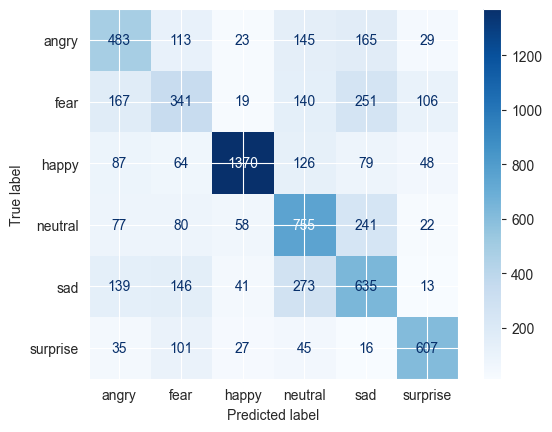

              precision    recall  f1-score   support

       angry       0.49      0.50      0.50       958
        fear       0.40      0.33      0.36      1024
       happy       0.89      0.77      0.83      1774
     neutral       0.51      0.61      0.56      1233
         sad       0.46      0.51      0.48      1247
    surprise       0.74      0.73      0.73       831

    accuracy                           0.59      7067
   macro avg       0.58      0.58      0.58      7067
weighted avg       0.60      0.59      0.60      7067



In [18]:
create_confusion_matrix(efficientnet_b0_trained, device, test_loader, test_dataset.classes,
                        'cm_efficientnet_b0_trained_02.png')

Final Test Accuracy: 73.20%


<Figure size 800x600 with 0 Axes>

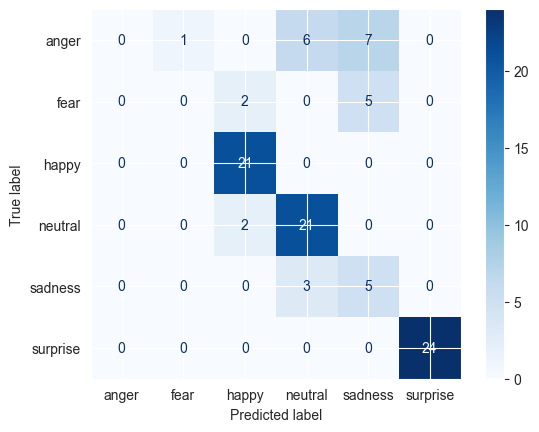

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        14
        fear       0.00      0.00      0.00         7
       happy       0.84      1.00      0.91        21
     neutral       0.70      0.91      0.79        23
     sadness       0.29      0.62      0.40         8
    surprise       1.00      1.00      1.00        24

    accuracy                           0.73        97
   macro avg       0.47      0.59      0.52        97
weighted avg       0.62      0.73      0.67        97



C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [43]:
create_confusion_matrix(efficientnet_b0_trained, device, test_loader_ck, test_dataset_ck.classes, 'cm_efficientnet_b0_trained_ck-dataset.png')

Final Test Accuracy: 46.74%


<Figure size 800x600 with 0 Axes>

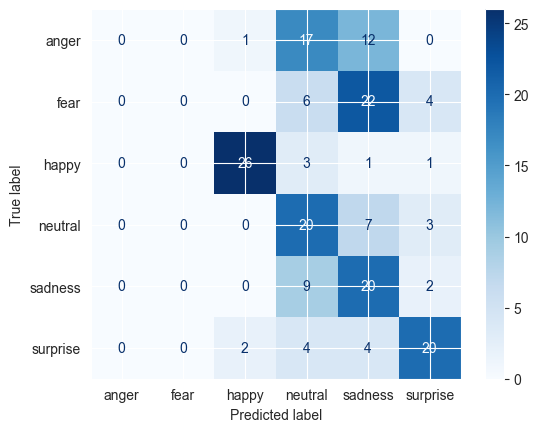

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        30
        fear       0.00      0.00      0.00        32
       happy       0.90      0.84      0.87        31
     neutral       0.34      0.67      0.45        30
     sadness       0.30      0.65      0.41        31
    surprise       0.67      0.67      0.67        30

    accuracy                           0.47       184
   macro avg       0.37      0.47      0.40       184
weighted avg       0.37      0.47      0.40       184



C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [44]:
create_confusion_matrix(efficientnet_b0_trained, device, test_loader_jaffe, test_dataset_jaffe.classes, 'cm_efficientnet_b0_trained_jaffe-dataset.png')

Final Test Accuracy: 64.81%


<Figure size 800x600 with 0 Axes>

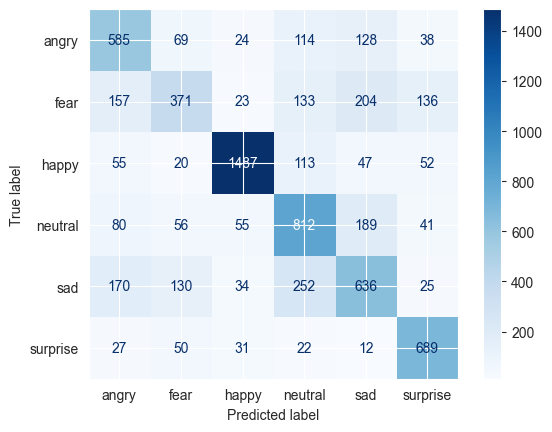

              precision    recall  f1-score   support

       angry       0.54      0.61      0.58       958
        fear       0.53      0.36      0.43      1024
       happy       0.90      0.84      0.87      1774
     neutral       0.56      0.66      0.61      1233
         sad       0.52      0.51      0.52      1247
    surprise       0.70      0.83      0.76       831

    accuracy                           0.65      7067
   macro avg       0.63      0.63      0.63      7067
weighted avg       0.65      0.65      0.64      7067



In [19]:
create_confusion_matrix(resnet_18_trained, device, test_loader, test_dataset.classes, 'cm_resnet_18_trained_02.png')

Final Test Accuracy: 72.16%


<Figure size 800x600 with 0 Axes>

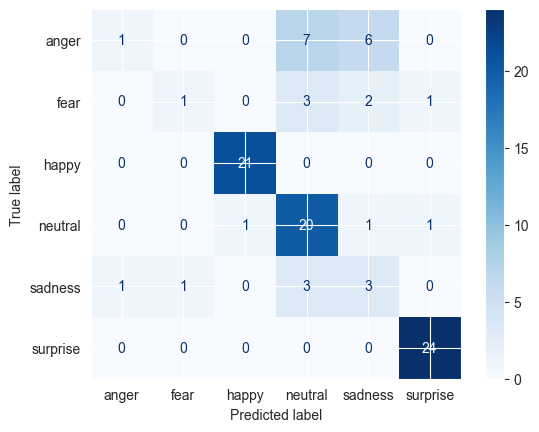

              precision    recall  f1-score   support

       anger       0.50      0.07      0.12        14
        fear       0.50      0.14      0.22         7
       happy       0.95      1.00      0.98        21
     neutral       0.61      0.87      0.71        23
     sadness       0.25      0.38      0.30         8
    surprise       0.92      1.00      0.96        24

    accuracy                           0.72        97
   macro avg       0.62      0.58      0.55        97
weighted avg       0.71      0.72      0.68        97



In [45]:
create_confusion_matrix(resnet_18_trained, device, test_loader_ck, test_dataset_ck.classes, 'cm_resnet_18_trained_ck-dataset.png')

Final Test Accuracy: 53.26%


<Figure size 800x600 with 0 Axes>

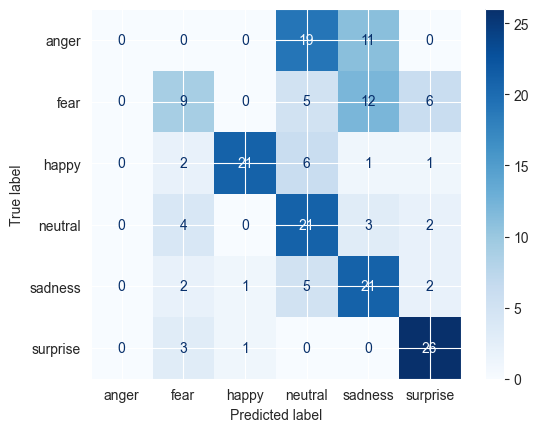

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        30
        fear       0.45      0.28      0.35        32
       happy       0.91      0.68      0.78        31
     neutral       0.38      0.70      0.49        30
     sadness       0.44      0.68      0.53        31
    surprise       0.70      0.87      0.78        30

    accuracy                           0.53       184
   macro avg       0.48      0.53      0.49       184
weighted avg       0.48      0.53      0.49       184



C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [46]:
create_confusion_matrix(resnet_18_trained, device, test_loader_jaffe, test_dataset_jaffe.classes, 'cm_resnet_18_trained_jaffe-dataset.png')

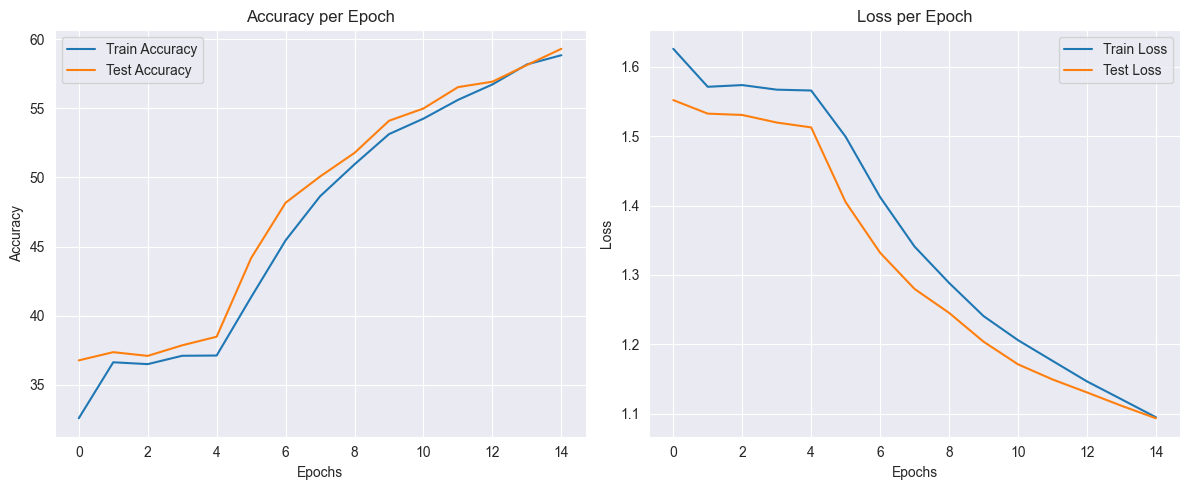

In [20]:
accuracy_and_loss_graphs(history_efficientnet, 'acc_loss_efficientnet_02.png')

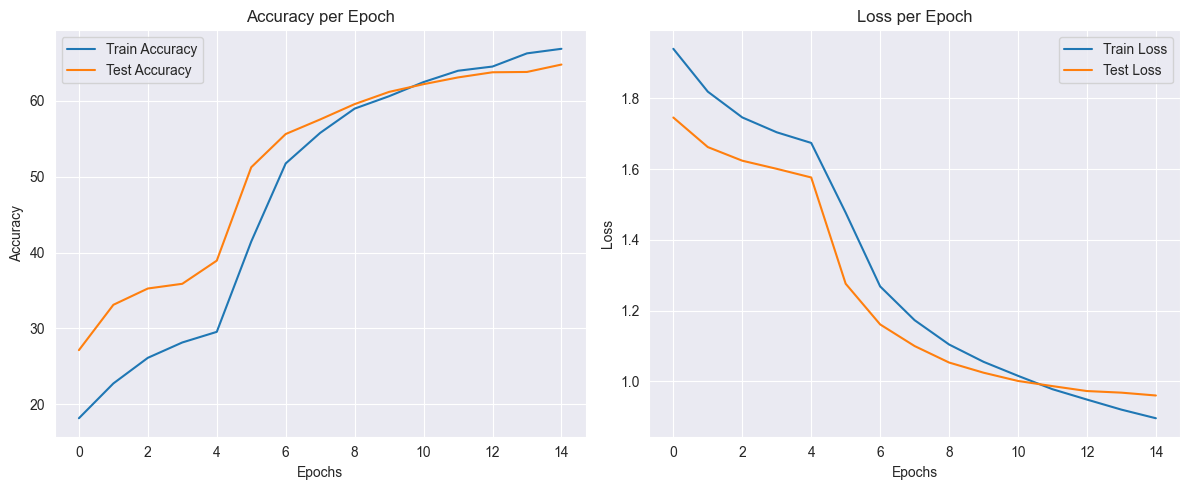

In [22]:
accuracy_and_loss_graphs(history_resnet, 'acc_loss_resnet_02.png')

## VGG16

### DataPreparations

In [23]:
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  #VGG16 input size
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 28273 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.


In [24]:
def preprocess_data_generator(directory, batch_size=32, is_test=False):
    image_files = [f for f in os.listdir(directory) if f.endswith('.jpg') or f.endswith('.png')]
    images = []
    labels = []

    for file in image_files:
        image_path = os.path.join(directory, file)
        print(image_path)
        img = cv2.imread(image_path)

        # Detect face from the image
        face = detect_face(img)

        if face is not None:
            # Resize the face image and normalize it (VGG16 input size is 224*244)
            face = np.expand_dims(face, axis=0)  # Add batch dimension
            face = np.array(face)  # Convert to numpy array

            # Get corresponding label (assuming label is part of filename, modify as needed)
            label = int(file.split('_')[0])

            images.append(face)
            labels.append(label)

    images = np.array(images)
    labels = np.array(labels)

    # Convert to categorical labels
    labels = keras.utils.to_categorical(labels, num_classes=6)

    return images, labels

In [25]:
train_images, train_labels = preprocess_data_generator(train_dir)
test_images, test_labels = preprocess_data_generator(test_dir)

### Training of model

In [26]:
# Load pre-trained VGG16 model (excluding the top layer)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze convolutional base (don´t train these layers)
for layer in base_model.layers:
    layer.trainable = False

#base_model.summary()

In [27]:
# Correctly connect new classification layers
x = Flatten()(base_model.output)  # Flatten the output of convolutional base
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(6, activation='softmax')(x)  # Final output layer

# Create the model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy',
              metrics=['accuracy'])

#model.summary()

In [28]:
# Train the model
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(test_generator)
)

# Evaluate on the test dataset
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test loss: {test_loss * 100:.2f}; Test accuracy: {test_acc * 100:.2f}')

Epoch 1/15
884/884 ━━━━━━━━━━━━━━━━━━━━ 1948s 2s/step - accuracy: 0.3151 - loss: 1.6610 - val_accuracy: 0.4112 - val_loss: 1.5288
Epoch 2/15
884/884 ━━━━━━━━━━━━━━━━━━━━ 1942s 2s/step - accuracy: 0.3674 - loss: 1.5663 - val_accuracy: 0.4200 - val_loss: 1.4636
Epoch 3/15
884/884 ━━━━━━━━━━━━━━━━━━━━ 1908s 2s/step - accuracy: 0.3915 - loss: 1.5220 - val_accuracy: 0.4535 - val_loss: 1.4290
Epoch 4/15
884/884 ━━━━━━━━━━━━━━━━━━━━ 1908s 2s/step - accuracy: 0.3988 - loss: 1.5008 - val_accuracy: 0.4541 - val_loss: 1.4040
Epoch 5/15
884/884 ━━━━━━━━━━━━━━━━━━━━ 1913s 2s/step - accuracy: 0.4121 - loss: 1.4843 - val_accuracy: 0.4590 - val_loss: 1.3834
Epoch 6/15
884/884 ━━━━━━━━━━━━━━━━━━━━ 1914s 2s/step - accuracy: 0.4192 - loss: 1.4661 - val_accuracy: 0.4665 - val_loss: 1.3809
Epoch 7/15
884/884 ━━━━━━━━━━━━━━━━━━━━ 1915s 2s/step - accuracy: 0.4229 - loss: 1.4627 - val_accuracy: 0.4674 - val_loss: 1.3697
Epoch 8/15
884/884 ━━━━━━━━━━━━━━━━━━━━ 1903s 2s/step - accuracy: 0.4284 - loss: 1.4499 - 

In [29]:
model.save('vgg16_trained.h5')

### Graph Functions

In [30]:
def acc_and_loss_vgg16(history, save_path):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label="Train Accuracy")
    plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.savefig(save_path, dpi=300)

    plt.show()

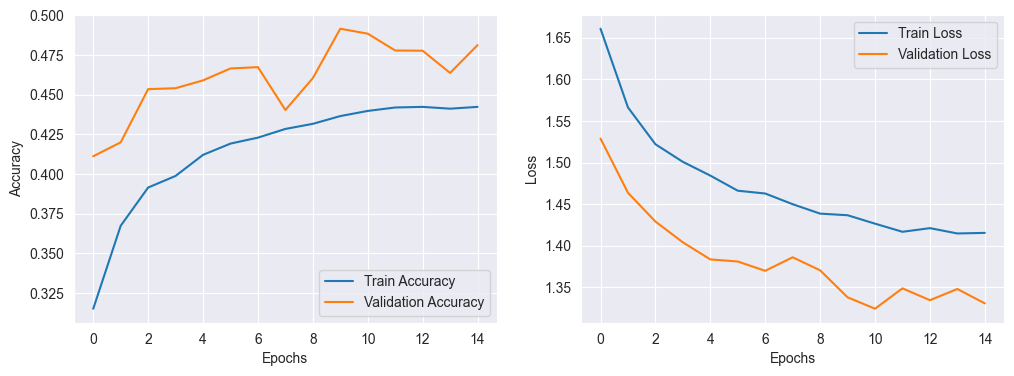

In [37]:
acc_and_loss_vgg16(history, 'acc_loss_vgg16.png')

In [31]:
def conf_matrix_vgg16(test_dir, model, save_path):
    eval_test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    predictions = model.predict(eval_test_generator)
    predicted_classes = np.argmax(predictions, axis=1)

    true_classes = eval_test_generator.classes

    class_labels = list(eval_test_generator.class_indices.keys())

    cm = confusion_matrix(true_classes, predicted_classes)
    cr = classification_report(true_classes, predicted_classes, target_names=class_labels)

    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap='Blues', xticks_rotation='vertical')
    plt.title('Confusion Matrix')

    plt.savefig(save_path, dpi=300)

    plt.show()

    print(cr)

Found 7067 images belonging to 6 classes.
221/221 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step


<Figure size 800x600 with 0 Axes>

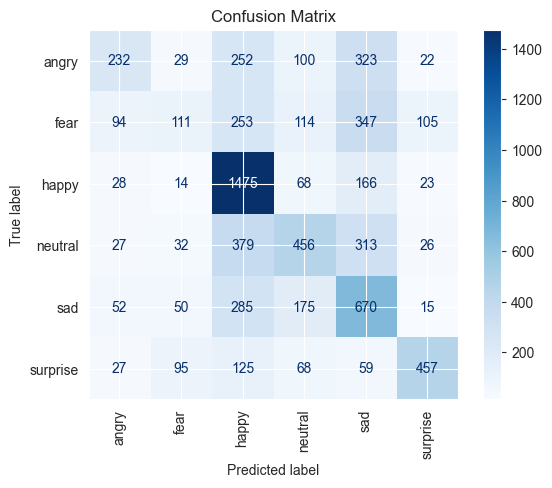

              precision    recall  f1-score   support

       angry       0.50      0.24      0.33       958
        fear       0.34      0.11      0.16      1024
       happy       0.53      0.83      0.65      1774
     neutral       0.46      0.37      0.41      1233
         sad       0.36      0.54      0.43      1247
    surprise       0.71      0.55      0.62       831

    accuracy                           0.48      7067
   macro avg       0.48      0.44      0.43      7067
weighted avg       0.48      0.48      0.45      7067



In [38]:
conf_matrix_vgg16(test_dir, model, 'conf_matrix_vgg16.png')

Found 97 images belonging to 6 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step


C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

<Figure size 800x600 with 0 Axes>

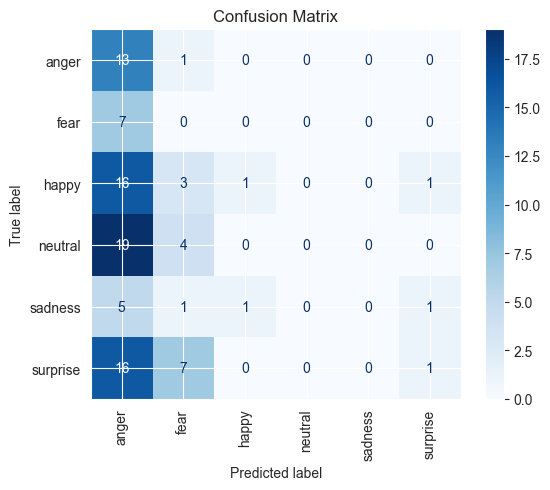

              precision    recall  f1-score   support

       anger       0.17      0.93      0.29        14
        fear       0.00      0.00      0.00         7
       happy       0.50      0.05      0.09        21
     neutral       0.00      0.00      0.00        23
     sadness       0.00      0.00      0.00         8
    surprise       0.33      0.04      0.07        24

    accuracy                           0.15        97
   macro avg       0.17      0.17      0.07        97
weighted avg       0.22      0.15      0.08        97



In [48]:
conf_matrix_vgg16(test_dir_ck, model, 'conf_matrix_vgg16_ck-dataset.png')

Found 184 images belonging to 6 classes.


C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\keras\src\legacy\preprocessing\image.py:149: UserWarning: Using ".tiff" files with multiple bands will cause distortion. Please verify your output.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

<Figure size 800x600 with 0 Axes>

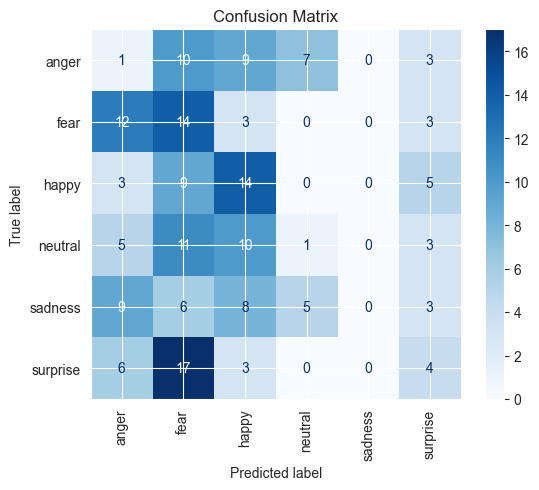

              precision    recall  f1-score   support

       anger       0.03      0.03      0.03        30
        fear       0.21      0.44      0.28        32
       happy       0.30      0.45      0.36        31
     neutral       0.08      0.03      0.05        30
     sadness       0.00      0.00      0.00        31
    surprise       0.19      0.13      0.16        30

    accuracy                           0.18       184
   macro avg       0.13      0.18      0.15       184
weighted avg       0.13      0.18      0.15       184



In [49]:
conf_matrix_vgg16(test_dir_jaffe, model, 'conf_matrix_vgg16_jaffe-dataset.png')

## Predictions

### Functions Resnet18 & EfficientNet-B0

In [32]:
def preprocess_face(face_bgr):
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)

    face_resized = cv2.resize(face_rgb, (244, 244))

    face_tensor = torch.from_numpy(face_resized).float() / 255.0
    face_tensor = face_tensor.permute(2, 0, 1)  # Change HWC to CHW

    face_batch = face_tensor.unsqueeze(0)

    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    face_batch = normalize(face_batch)

    return face_batch

In [33]:
def eval_model(model, face_roi, expressions):
    processed_face = preprocess_face(face_roi)

    model.eval()
    device = next(model.parameters()).device
    processed_face = processed_face.to(device)

    with torch.no_grad():
        output = model(processed_face)
        probs = torch.softmax(output, dim=1)

        # Get the index of the highest probability
        prediction_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][prediction_idx].item()

        # Map index to emotion string
        predicted_emotion = expressions[prediction_idx]

        return confidence, predicted_emotion

### Functions VGG16

In [34]:
def preprocess_face_vgg16(face_bgr):
    # VGG16 expects 3 channels (RGB). OpenCV reads in BGR, so we convert.
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
    face_resized = cv2.resize(face_rgb, (224, 224))

    # Normalize pixel values (to 0-1) to match your ImageDataGenerator(rescale=1./255)
    face_normalized = face_resized.astype("float32") / 255.0

    # Add batch dimension: (1, 224, 224, 3)
    face_batch = np.expand_dims(face_normalized, axis=0)
    return face_batch

In [35]:
def eval_model_vgg16(model, face_roi, expressions):
    processed_face = preprocess_face_vgg16(face_roi)

    # Get prediction
    prediction = model.predict(processed_face)
    predicted_class = np.argmax(prediction, axis=1)
    predicted_emotion = expressions[predicted_class[0]]
    confidence = np.max(prediction) * 100

    return confidence, predicted_emotion

## Predict Function

In [79]:
def predict_images(model, img_path, model_name, true_emotion, save_path):
    expressions = ['anger', 'fear', 'happy', 'neutral', 'sadness', 'surprise']

    # Path to the test image
    #img_path = '../Data/assignment/CK_dataset/happy/20251201_195833.jpg'
    #img_path = '../Data/assignment/CK_dataset/neutral/20251201_200909.jpg'

    original_img = cv2.imread(img_path)
    if original_img is None:
        print(f"Error: Could not load image at {img_path}")
    else:
        gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray_img, scaleFactor=1.3, minNeighbors=5)

        face_detected_img = original_img.copy()
        final_img = original_img.copy()

        for (x, y, w, h) in faces:
            face_roi = original_img[y:y + h, x:x + w]

            if model_name == "VGG16":
                confidence, predicted_emotion = eval_model_vgg16(model, face_roi, expressions)
            else:
                confidence, predicted_emotion = eval_model(model, face_roi, expressions)

            cv2.rectangle(face_detected_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
            cv2.rectangle(final_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

            label = f"{predicted_emotion} ({confidence:.1f}%)"
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 1.0
            font_thickness = 2

            (text_width, text_height), _ = cv2.getTextSize(label, font, font_scale, font_thickness)
            cv2.rectangle(final_img, (x, y - text_height - 10), (x + text_width, y), (0, 255, 0), -1)
            cv2.putText(final_img, label, (x, y - 5), font, font_scale, (0, 0, 0), font_thickness)

        original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        face_detected_img_rgb = cv2.cvtColor(face_detected_img, cv2.COLOR_BGR2RGB)
        final_img_rgb = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].imshow(original_img_rgb)
        axes[0].set_title(f"Original Image - {true_emotion}")
        axes[0].axis("off")

        axes[1].imshow(face_detected_img_rgb)
        axes[1].set_title("Detection Only")
        axes[1].axis("off")

        axes[2].imshow(final_img_rgb)
        axes[2].set_title(f"{model_name} Prediction")
        axes[2].axis("off")

        plt.savefig(save_path)

        plt.show()

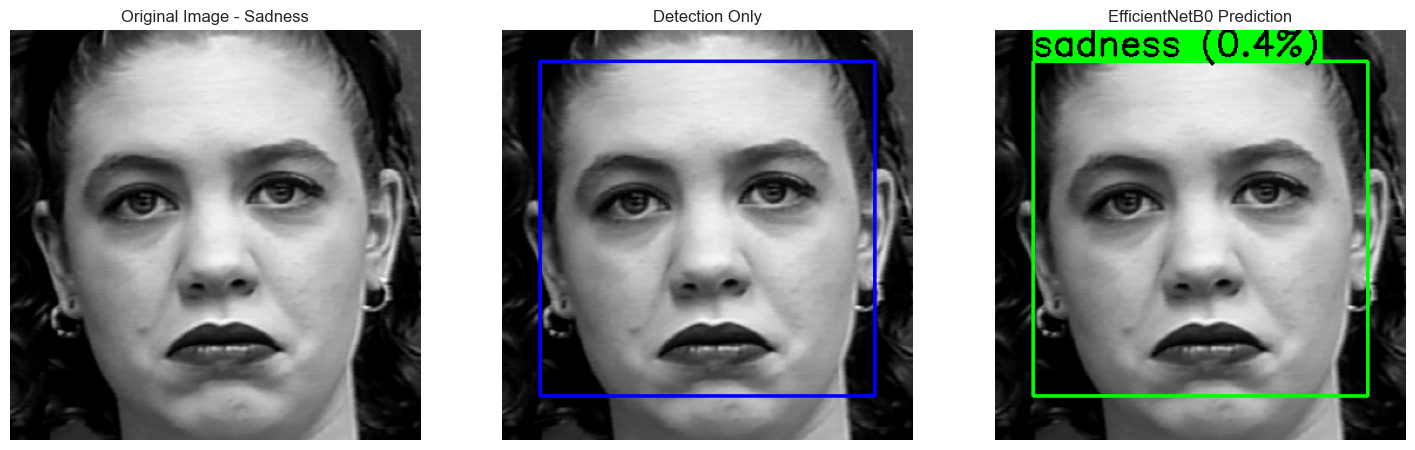

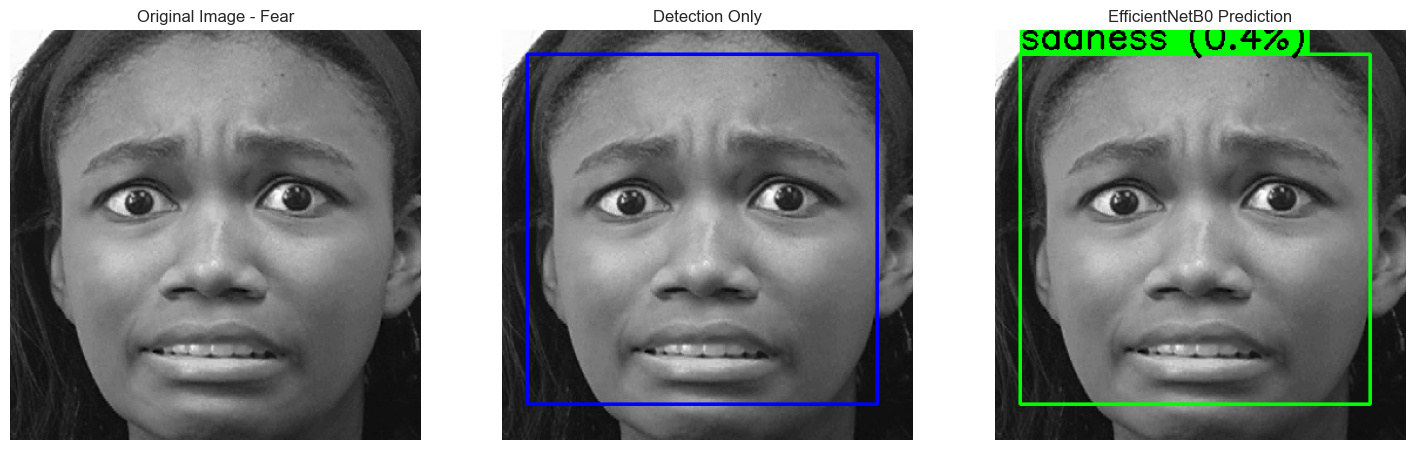

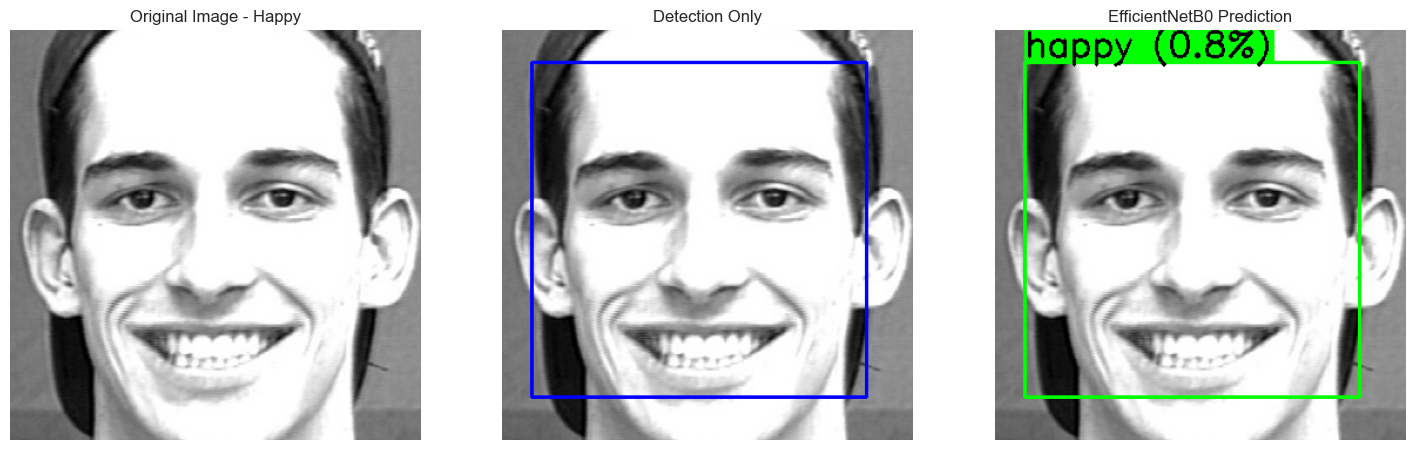

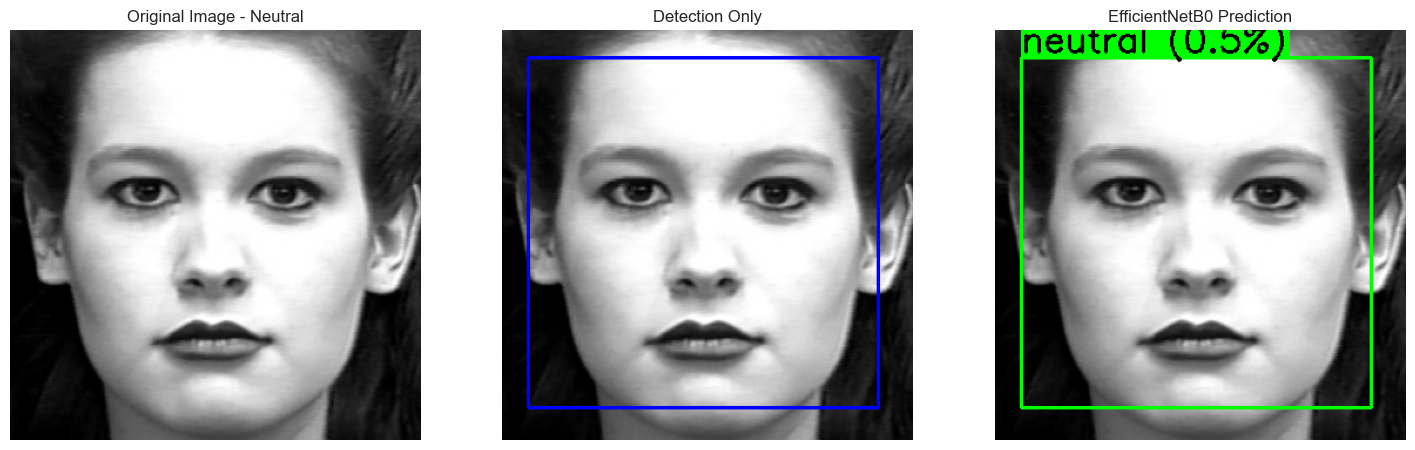

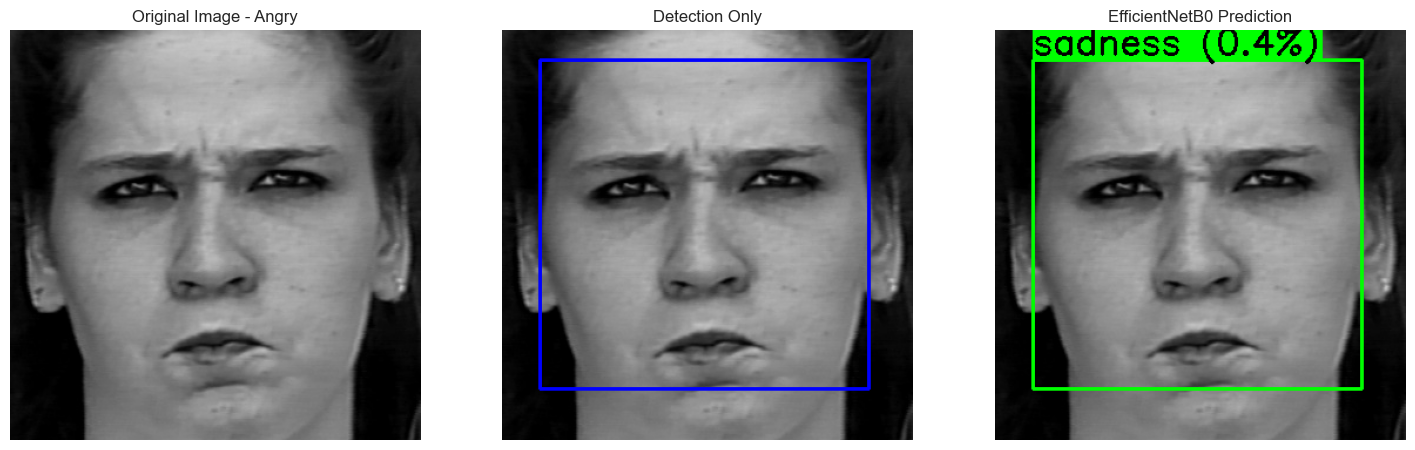

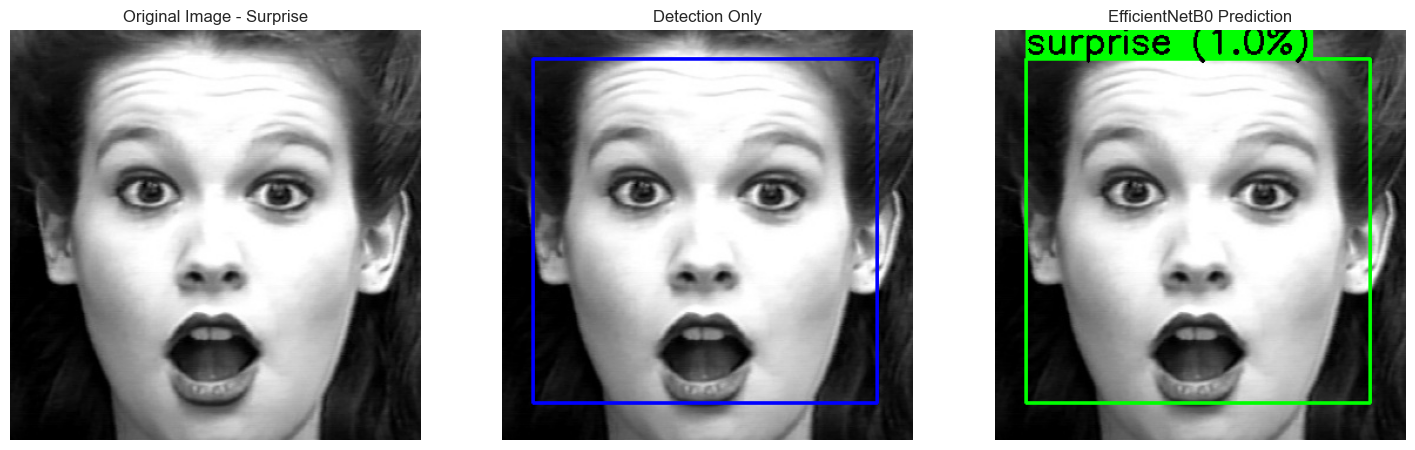

In [80]:
predict_images(efficientnet_b0_trained, '../Data/TestData/3.jpg', 'EfficientNetB0', 'Sadness', 'Predictions/EfficientNetB0_Sadness.png')
predict_images(efficientnet_b0_trained, '../Data/TestData/4.jpg', 'EfficientNetB0', 'Fear', 'Predictions/EfficientNetB0_Fear.png')
predict_images(efficientnet_b0_trained, '../Data/TestData/21.jpg', 'EfficientNetB0', 'Happy', 'Predictions/EfficientNetB0_Happy.png')
predict_images(efficientnet_b0_trained, '../Data/TestData/31.jpg', 'EfficientNetB0', 'Neutral', 'Predictions/EfficientNetB0_Neutral.png')
predict_images(efficientnet_b0_trained, '../Data/TestData/41.jpg', 'EfficientNetB0', 'Angry', 'Predictions/EfficientNetB0_Angry.png')
predict_images(efficientnet_b0_trained, '../Data/TestData/74.jpg', 'EfficientNetB0', 'Surprise', 'Predictions/EfficientNetB0_Surprise.png')

In [ ]:
# predict_images(efficientnet_b0_trained, '../Data/TestData/20251201_195833.jpg', 'EfficientNetB0')
# predict_images(efficientnet_b0_trained, '../Data/TestData/20251201_200925.jpg', 'EfficientNetB0')
# predict_images(efficientnet_b0_trained, '../Data/TestData/20251201_200945.jpg', 'EfficientNetB0')
# predict_images(efficientnet_b0_trained, '../Data/TestData/20251201_200909.jpg', 'EfficientNetB0')
# predict_images(efficientnet_b0_trained, '../Data/TestData/20251201_195843.jpg', 'EfficientNetB0')
# predict_images(efficientnet_b0_trained, '../Data/TestData/20251201_195838.jpg', 'EfficientNetB0')
# predict_images(efficientnet_b0_trained, '../Data/TestData/20251201_195831.jpg', 'EfficientNetB0')

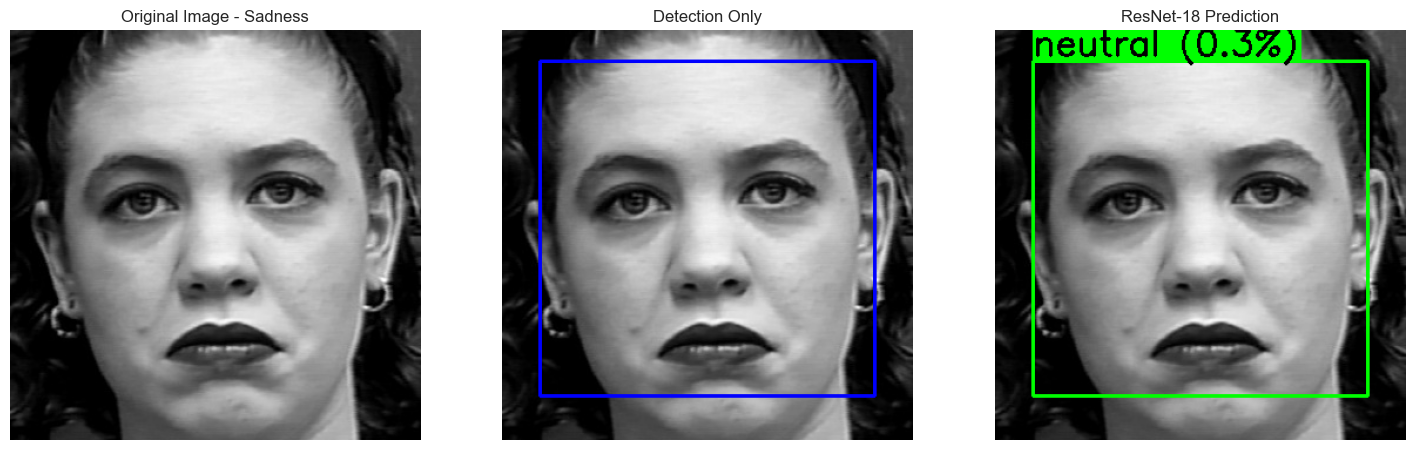

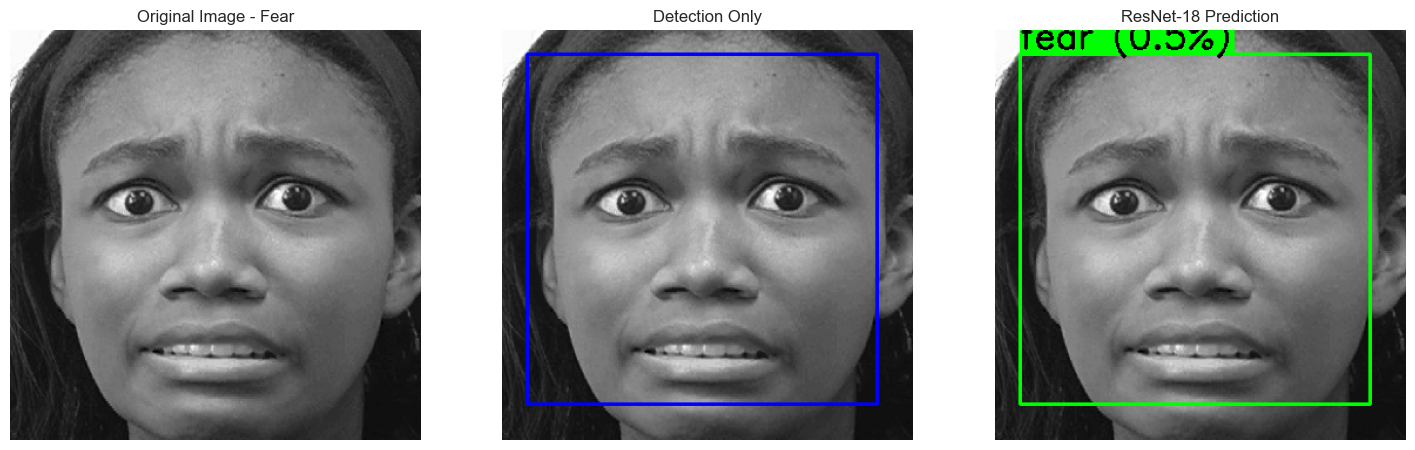

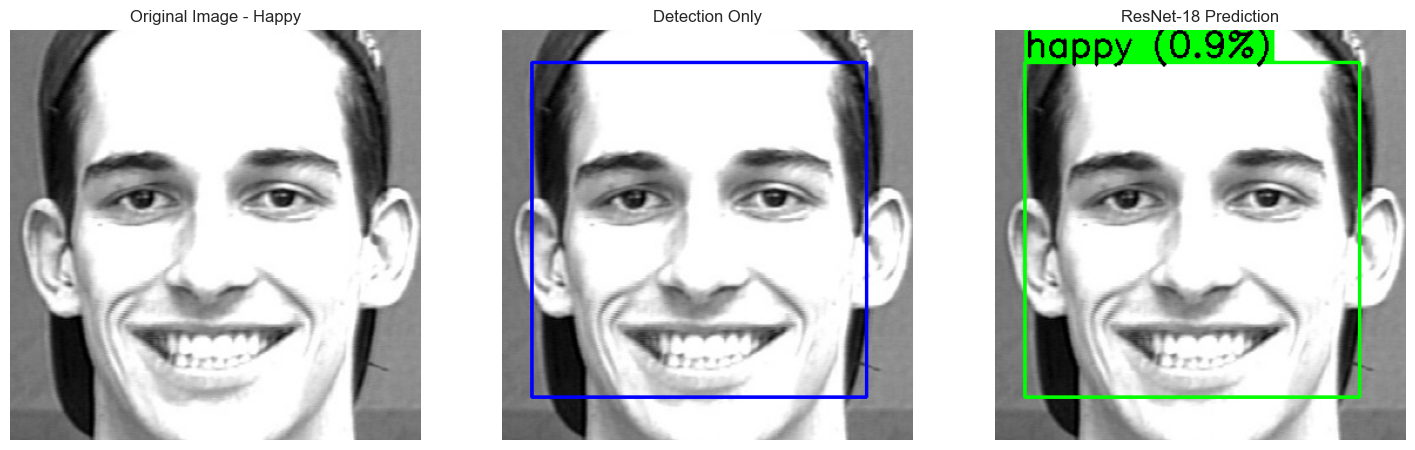

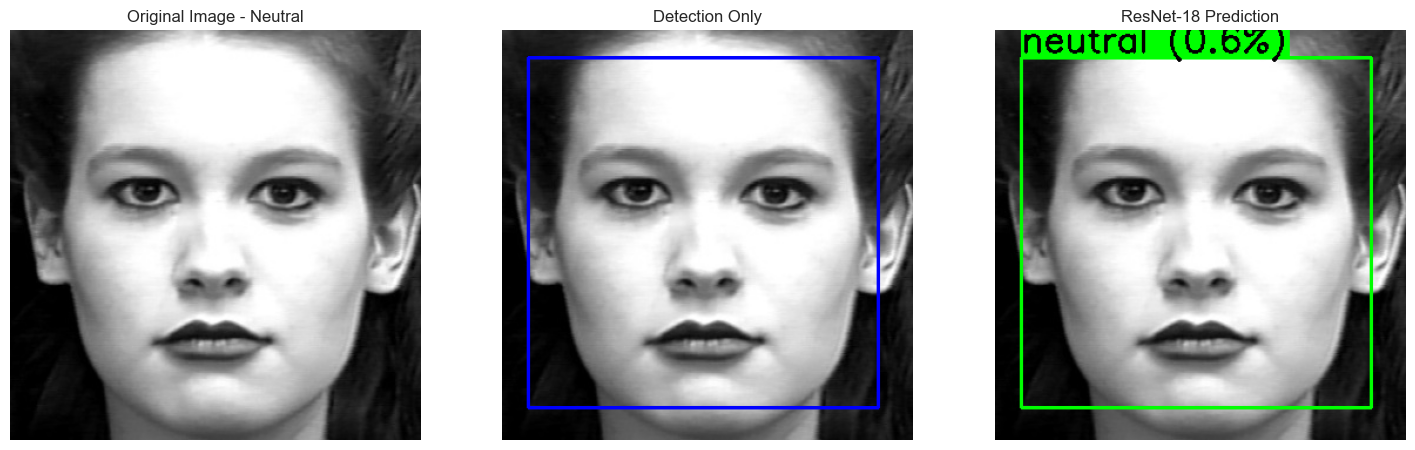

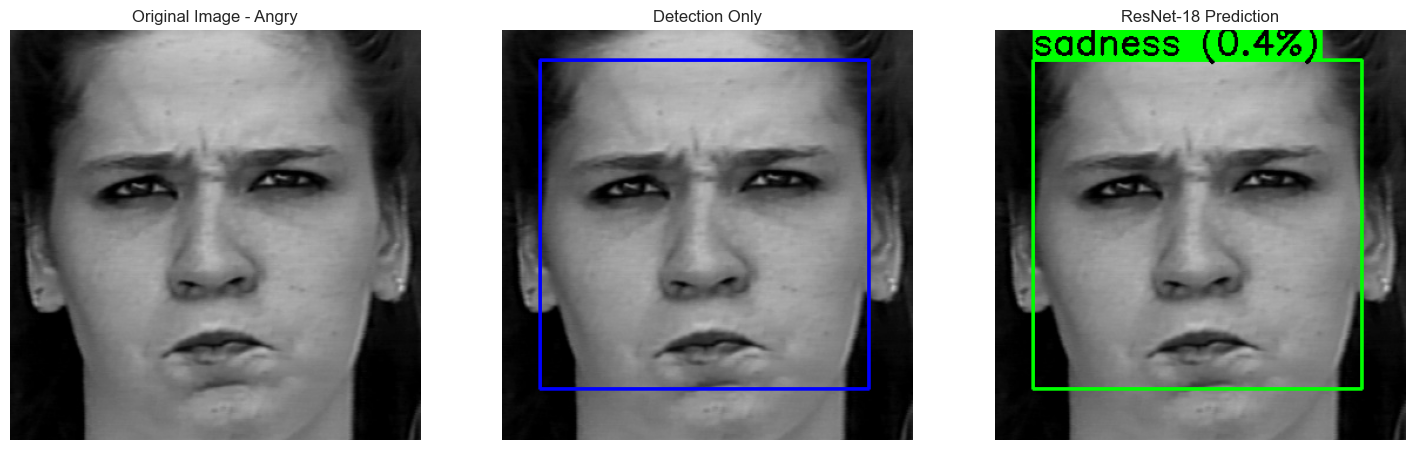

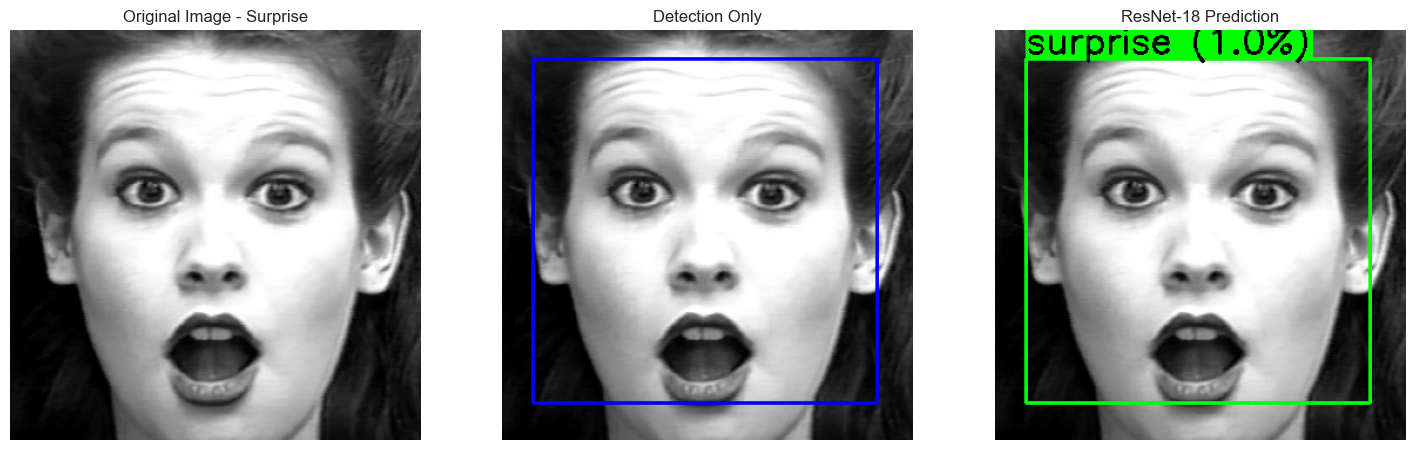

In [61]:
predict_images(resnet_18_trained, '../Data/TestData/3.jpg', 'ResNet-18', 'Sadness', 'Predictions/ResNet18_Sadness.png')
predict_images(resnet_18_trained, '../Data/TestData/4.jpg', 'ResNet-18', 'Fear', 'Predictions/ResNet18_Fear.png')
predict_images(resnet_18_trained, '../Data/TestData/21.jpg', 'ResNet-18', 'Happy', 'Predictions/ResNet18_Happy.png')
predict_images(resnet_18_trained, '../Data/TestData/31.jpg', 'ResNet-18', 'Neutral', 'Predictions/ResNet18_Neutral.png')
predict_images(resnet_18_trained, '../Data/TestData/41.jpg', 'ResNet-18', 'Angry', 'Predictions/ResNet18_Angry.png')
predict_images(resnet_18_trained, '../Data/TestData/74.jpg', 'ResNet-18', 'Surprise', 'Predictions/ResNet18_Surprise.png')

In [ ]:
# predict_images(resnet_18_trained, '../Data/TestData/20251201_195833.jpg', 'ResNet-18')
# predict_images(resnet_18_trained, '../Data/TestData/20251201_200925.jpg', 'ResNet-18')
# predict_images(resnet_18_trained, '../Data/TestData/20251201_200945.jpg', 'ResNet-18')
# predict_images(resnet_18_trained, '../Data/TestData/20251201_200909.jpg', 'ResNet-18')
# predict_images(resnet_18_trained, '../Data/TestData/20251201_195843.jpg', 'ResNet-18')
# predict_images(resnet_18_trained, '../Data/TestData/20251201_195838.jpg', 'ResNet-18')
# predict_images(resnet_18_trained, '../Data/TestData/20251201_195831.jpg', 'ResNet-18')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


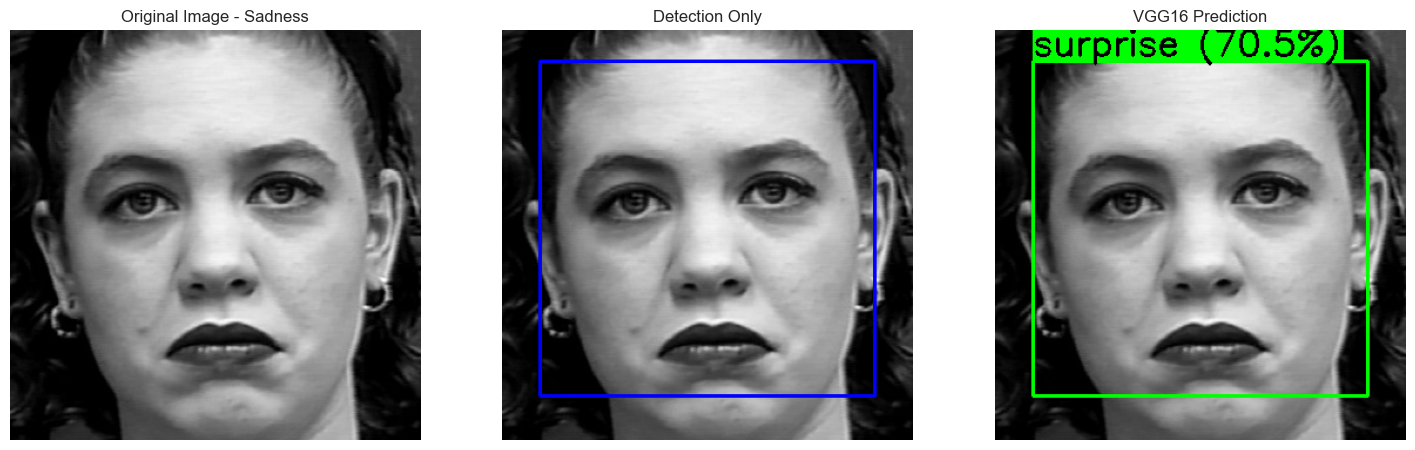

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


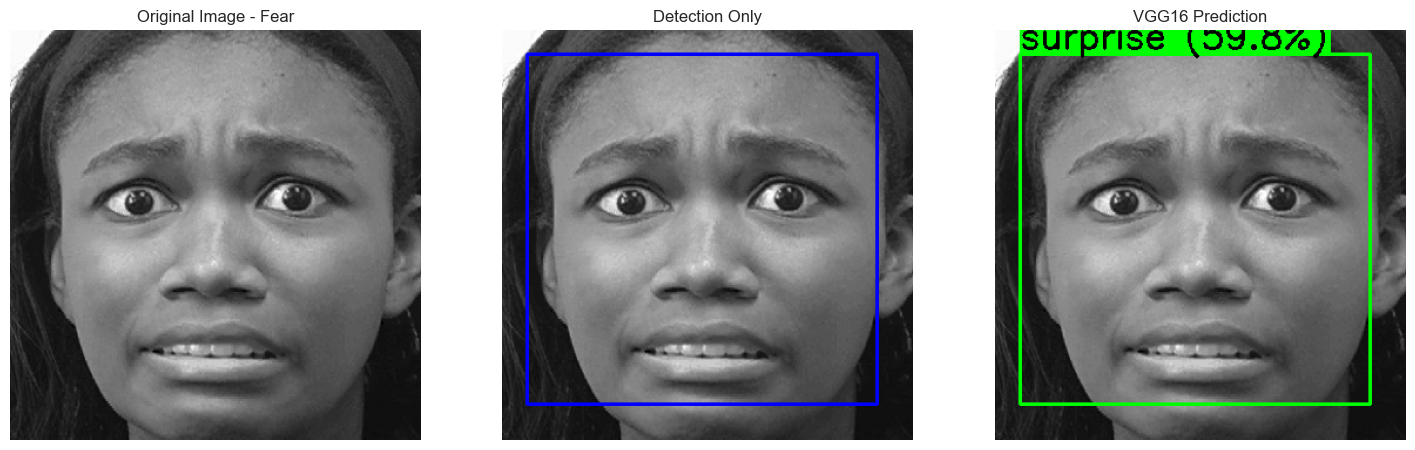

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


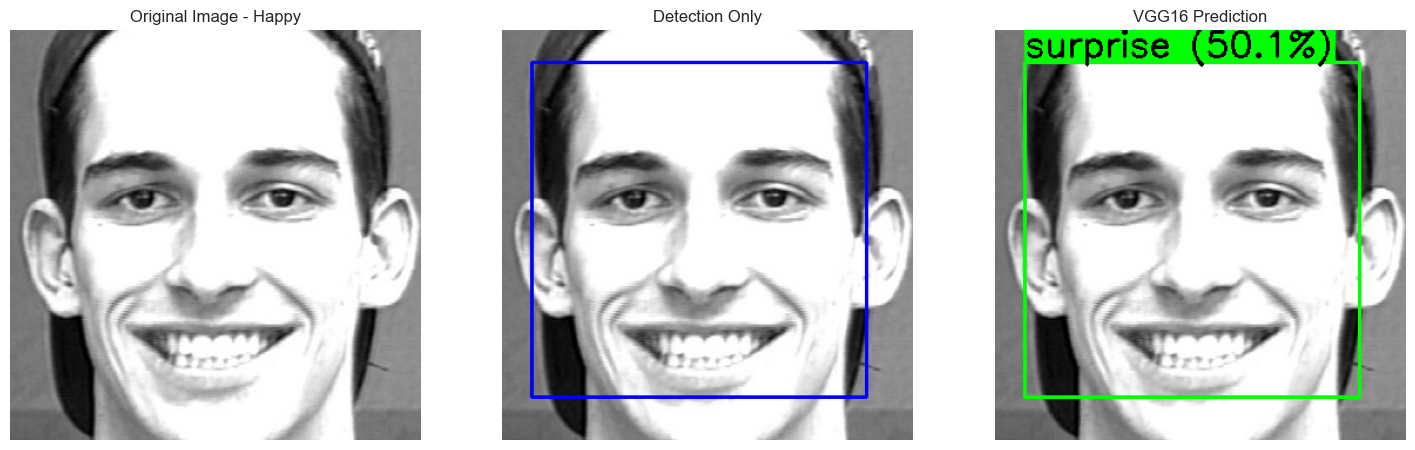

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


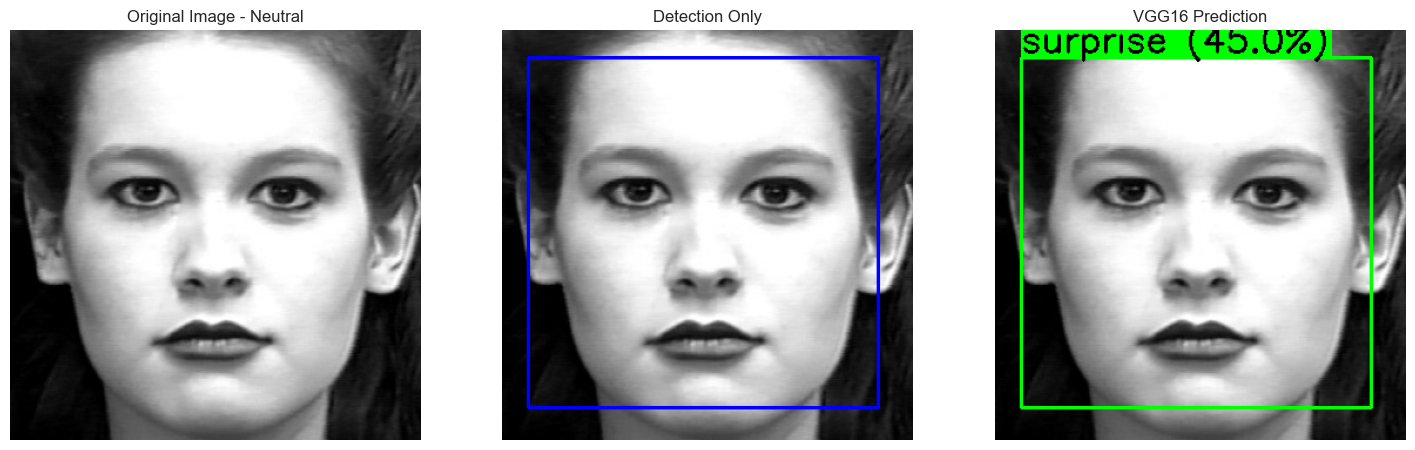

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


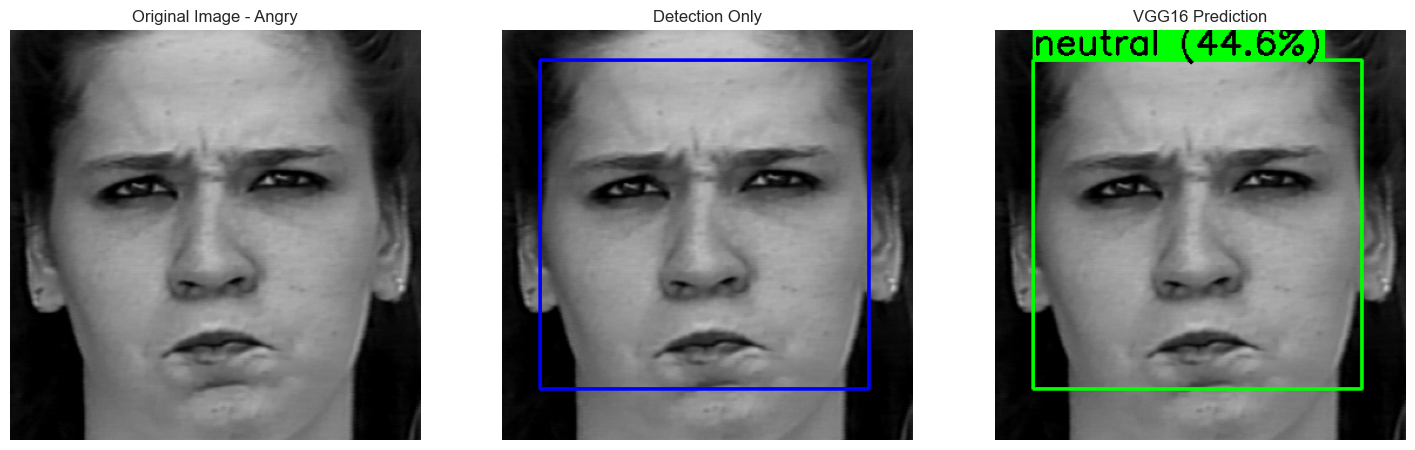

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


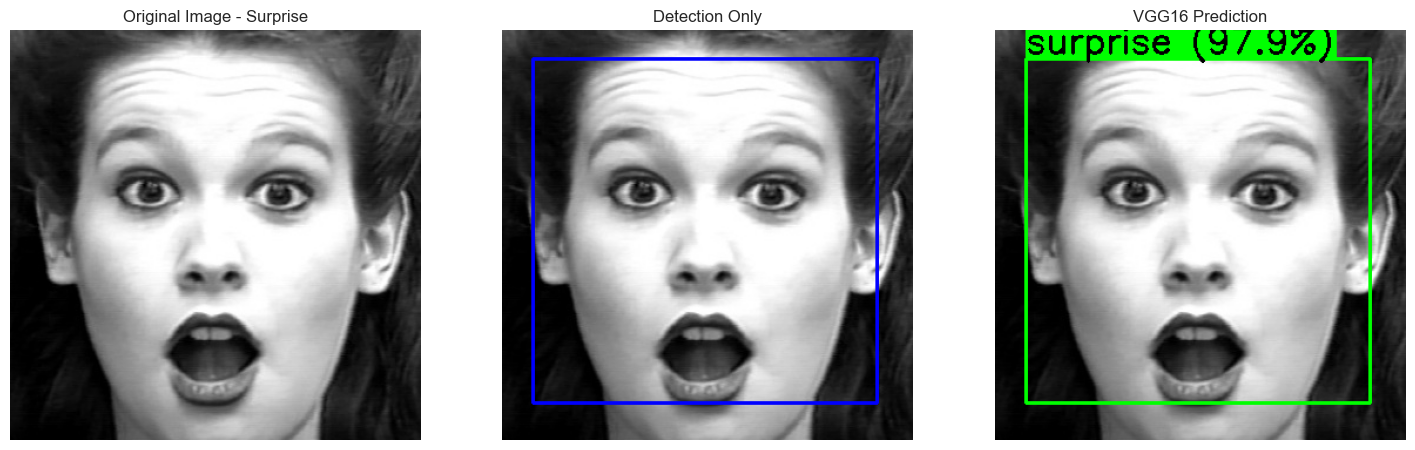

In [62]:
predict_images(model, '../Data/TestData/3.jpg', 'VGG16', 'Sadness', 'Predictions/VGG16_Sadness.png')
predict_images(model, '../Data/TestData/4.jpg', 'VGG16', 'Fear', 'Predictions/VGG16_Fear.png')
predict_images(model, '../Data/TestData/21.jpg', 'VGG16', 'Happy', 'Predictions/VGG16_Happy.png')
predict_images(model, '../Data/TestData/31.jpg', 'VGG16', 'Neutral', 'Predictions/VGG16_Neutral.png')
predict_images(model, '../Data/TestData/41.jpg', 'VGG16', 'Angry', 'Predictions/VGG16_Angry.png')
predict_images(model, '../Data/TestData/74.jpg', 'VGG16', 'Surprise', 'Predictions/VGG16_Surprise.png')

In [ ]:
# predict_images(model, '../Data/TestData/20251201_195833.jpg', 'VGG16')
# predict_images(model, '../Data/TestData/20251201_200925.jpg', 'VGG16')
# predict_images(model, '../Data/TestData/20251201_200945.jpg', 'VGG16')
# predict_images(model, '../Data/TestData/20251201_200909.jpg', 'VGG16')
# predict_images(model, '../Data/TestData/20251201_195843.jpg', 'VGG16')
# predict_images(model, '../Data/TestData/20251201_195838.jpg', 'VGG16')
# predict_images(model, '../Data/TestData/20251201_195831.jpg', 'VGG16')